In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the CSV files
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [73]:
print("Training data:")
print(train.columns)
# check multiple cabins
multiple_cabins = [item for item in train.Cabin if pd.notna(item) and len(item.split(' ')) > 1]
letter_tickets = [item for item in train.Ticket if len(item.split(' ')) > 1]
letter_tickets


Training data:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'train_test',
       'cabin_multiple', 'cabin_adv'],
      dtype='object')


['A/5 21171',
 'PC 17599',
 'STON/O2. 3101282',
 'PP 9549',
 'A/5. 2151',
 'PC 17601',
 'PC 17569',
 'C.A. 24579',
 'PC 17604',
 'A./5. 2152',
 'SC/Paris 2123',
 'S.C./A.4. 23567',
 'A/4. 39886',
 'PC 17572',
 'C.A. 31026',
 'C.A. 34651',
 'CA 2144',
 'PC 17605',
 'C.A. 29395',
 'S.P. 3464',
 'C.A. 33111',
 'CA 2144',
 'S.O.C. 14879',
 'SO/C 14885',
 'W./C. 6608',
 'SOTON/OQ 392086',
 'W.E.P. 5734',
 'C.A. 2315',
 'PC 17754',
 'PC 17759',
 'STON/O 2. 3101294',
 'PC 17558',
 'S.O.C. 14879',
 'A4. 54510',
 'C 17369',
 'SOTON/O.Q. 3101307',
 'A/5. 3337',
 'C.A. 29178',
 'SC/PARIS 2133',
 'PC 17593',
 'STON/O2. 3101279',
 'C.A. 33112',
 'W./C. 6608',
 'S.O.P. 1166',
 'A.5. 11206',
 'A/5. 851',
 'Fa 265302',
 'PC 17597',
 'SOTON/OQ 392090',
 'CA. 2343',
 'C.A. 33595',
 'PC 17318',
 'STON/O 2. 3101280',
 'PC 17595',
 'CA. 2343',
 'SC/PARIS 2131',
 'PC 17610',
 'PC 17569',
 'CA. 2343',
 'A/5 3540',
 'SOTON/O.Q. 3101311',
 'F.C.C. 13528',
 'A/5 21174',
 'STON/O2. 3101283',
 'W/C 14208',
 'SOTO

In [26]:
print("Testing data:")
test.head()

Testing data:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
train['train_test'] = 1
test['train_test'] = 0
test['Survived'] = np.nan
all_data = pd.concat([train, test], ignore_index=True)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
 12  train_test   1309 non-null   int64  
dtypes: float64(3), int64(5), object(5)
memory usage: 133.1+ KB


**Understanding nature of data**  
.info() .describe()  
histograms, metric correlations  
interesting themes  
feature engineering  

In [ ]:
all_data.info()
all_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
 12  train_test   1309 non-null   int64  
dtypes: float64(3), int64(5), object(5)
memory usage: 133.1+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,train_test
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,1309.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479,0.680672
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668,0.466394
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800,0.000000
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000,1.000000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200,1.000000


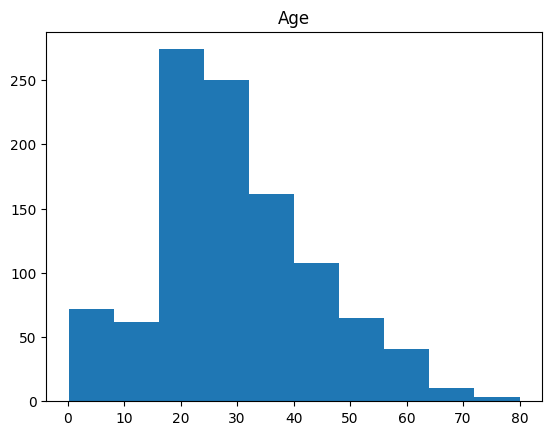

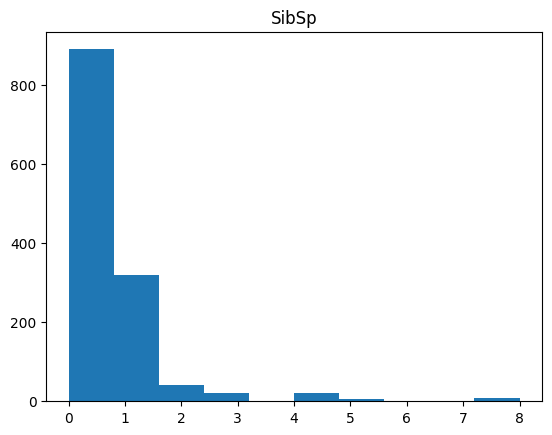

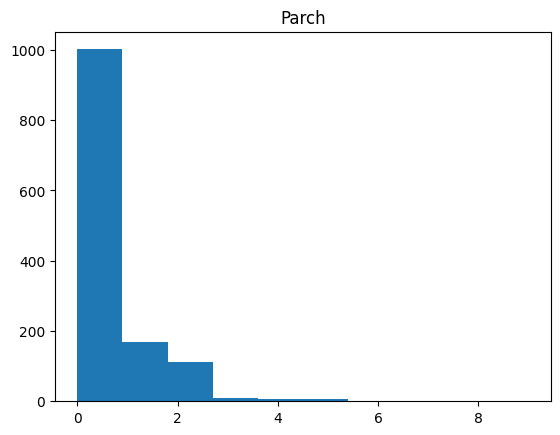

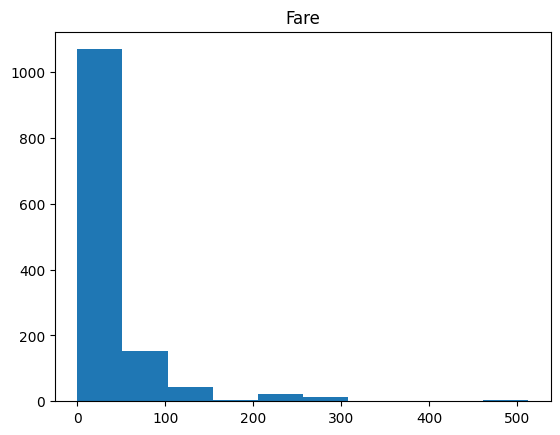

In [ ]:
# break code into numerical and categorical data frames
df_num = all_data[['Age', 'SibSp', 'Parch', 'Fare']]
df_cat = all_data[['Survived', 'Pclass', 'Ticket', 'Cabin', 'Sex', 'Embarked']]

# distributions for numerical data
for i in df_num.columns:
    plt.hist(df_num[i])
    plt.title(i)
    plt.show()

            Age     SibSp     Parch      Fare
Age    1.000000 -0.243699 -0.150917  0.178740
SibSp -0.243699  1.000000  0.373587  0.160238
Parch -0.150917  0.373587  1.000000  0.221539
Fare   0.178740  0.160238  0.221539  1.000000


<Axes: >

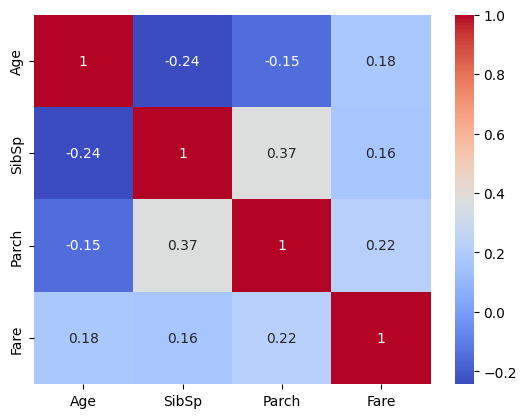

In [ ]:
# visualize correlations with heatmap and .corr() from pandas
print(df_num.corr())
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm')

**Observations**:  
age & siblings/spouses and age & parents/children have negative correlation  
siblings/spouses & parents/children have positive correlation (makes sense, multiple children means more siblings for those children)  
no multicollinearity --> good!

In [43]:
# compare survival rate across age, fare, parch, sibsp
pd.pivot_table(train, index='Survived', values=['Age', 'Fare', 'Parch', 'SibSp'], aggfunc='mean')

,Age,Fare,Parch,SibSp
Survived,,,,
0,30.626179,22.117887,0.329690,0.553734
1,28.343690,48.395408,0.464912,0.473684


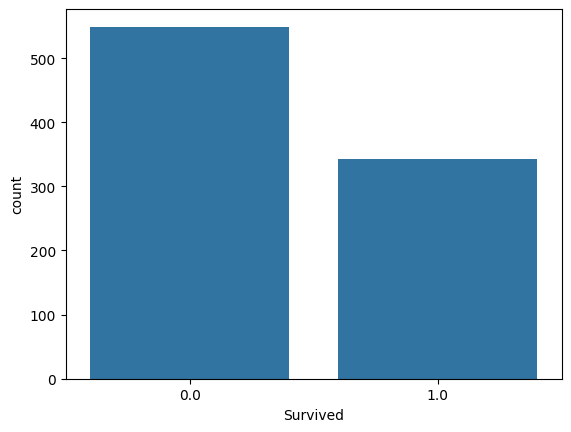

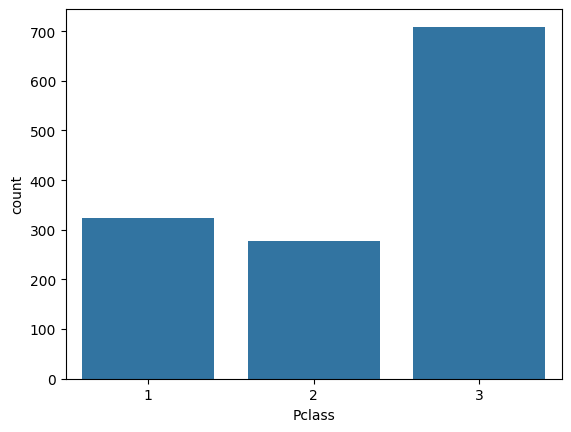

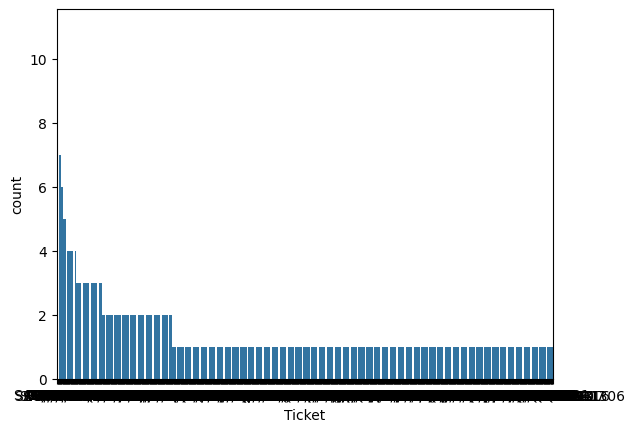

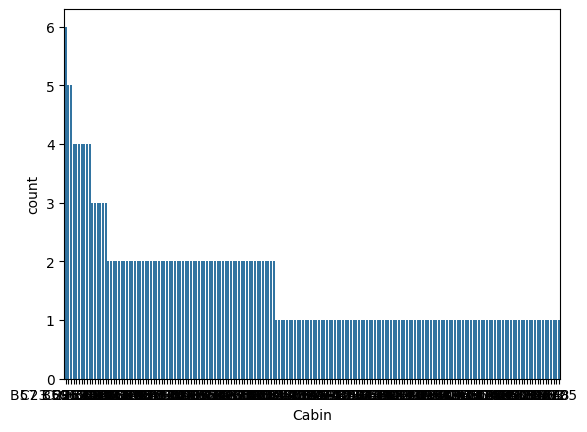

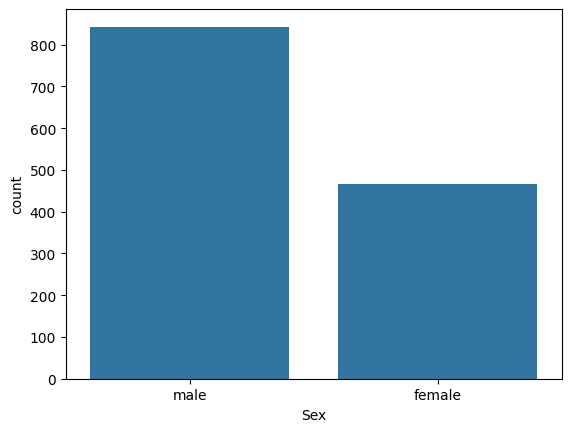

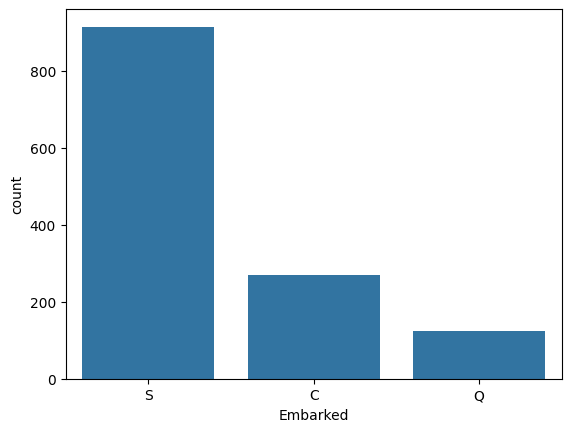

In [ ]:
# barplots for categorical data
for i in df_cat.columns:
    sns.barplot(x=df_cat[i].value_counts().index, y=df_cat[i].value_counts())
    plt.show()

In [50]:
# Comparing survival rate across categorical data
print(pd.pivot_table(train, index='Survived', columns='Sex', values='Ticket', aggfunc='count'))
print()
print(pd.pivot_table(train, index='Survived', columns='Pclass', values='Ticket', aggfunc='count'))
print()
print(pd.pivot_table(train, index='Survived', columns='Embarked', values='Ticket', aggfunc='count'))


Sex       female  male
Survived              
0             81   468
1            233   109

Pclass      1   2    3
Survived              
0          80  97  372
1         136  87  119

Embarked   C   Q    S
Survived             
0         75  47  427
1         93  30  217


**Feature Engineering**
1) Cabin—simplify to cabin letter (cabin_adv) or purchase of tickets across multiple cabins (cabin_multiple)  
2) Tickets—different ticket types

In [67]:
df_cat.Cabin
train['cabin_multiple'] = train['Cabin'].apply(lambda x: 0 if pd.isna(x) else len(x.split(' ')))
train['cabin_multiple'].value_counts()

cabin_multiple
0    687
1    180
2     16
3      6
4      2
Name: count, dtype: int64

In [68]:
pd.pivot_table(train, index='Survived', columns='cabin_multiple', values='Ticket', aggfunc='count')

cabin_multiple,0,1,2,3,4
Survived,,,,,
0,481.0,58.0,7.0,3.0,NaN
1,206.0,122.0,9.0,3.0,2.0


In [69]:
# creates categories based on cabin letter
# null values treated as own category
train['cabin_adv'] = train['Cabin'].apply(lambda x: x[0] if pd.notna(x) else 'N')
train['cabin_adv'].value_counts()

cabin_adv
N    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

In [70]:
pd.pivot_table(train, index='Survived', columns='cabin_adv', values='Ticket', aggfunc='count')

cabin_adv,A,B,C,D,E,F,G,N,T
Survived,,,,,,,,,
0,8.0,12.0,24.0,8.0,8.0,5.0,2.0,481.0,1.0
1,7.0,35.0,35.0,25.0,24.0,8.0,2.0,206.0,NaN


In [78]:
# understand ticket values better
# numeric vs non-numeric
training['ticket_numeric'] = training['Ticket'].apply(lambda x: 1 if x.isdigit() else 0)
training['ticket_letters'] = training.Ticket.apply(lambda x: ''.join(x.split(' ')[:-1]).replace('.', '').replace('/', '').lower() if len(x.split(' ')[:-1]) > 0 else 0)

In [79]:
pd.set_option("display.max_rows", None)
training['ticket_letters'].value_counts()

ticket_letters
0            665
pc            60
ca            41
a5            21
stono2        18
sotonoq       15
scparis       11
wc            10
a4             7
soc            6
fcc            5
c              5
sopp           3
pp             3
wep            3
ppp            2
scah           2
sotono2        2
swpp           2
fc             1
scahbasle      1
as             1
sp             1
sc             1
scow           1
fa             1
sop            1
sca4           1
casoton        1
Name: count, dtype: int64